# 01 — Exploratory Data Analysis
Understand the raw dataset before any modelling. This notebook covers:
- Dataset shape and column types
- Missing values and data quality
- Revenue and quantity distributions
- Top products and countries
- Sales trends over time
- Price distribution per product

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
PROCESSED = Path('../data/processed')
RAW = Path('../data/raw')
print('Libraries loaded')

Libraries loaded


## 1. Load raw data

In [2]:
df = pd.read_excel(RAW / 'Online Retail.xlsx', engine='openpyxl')
print(f'Shape: {df.shape}')
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2. Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct})[missing > 0]

,missing,pct
Description,1454,0.27
CustomerID,135080,24.93


## 3. Load cleaned data

In [5]:
tx = pd.read_parquet(PROCESSED / 'transactions.parquet')
products = pd.read_parquet(PROCESSED / 'product_features.parquet')
monthly = pd.read_parquet(PROCESSED / 'monthly_features.parquet')
print(f'Transactions : {len(tx):,}')
print(f'Products     : {len(products):,}')
print(f'Monthly rows : {len(monthly):,}')
tx.head()

Transactions : 396,777
Products     : 3,665
Monthly rows : 30,336


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,DayOfWeek,Hour
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2,8
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2,8
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2,8
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2,8
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2,8


## 4. Revenue and quantity distributions

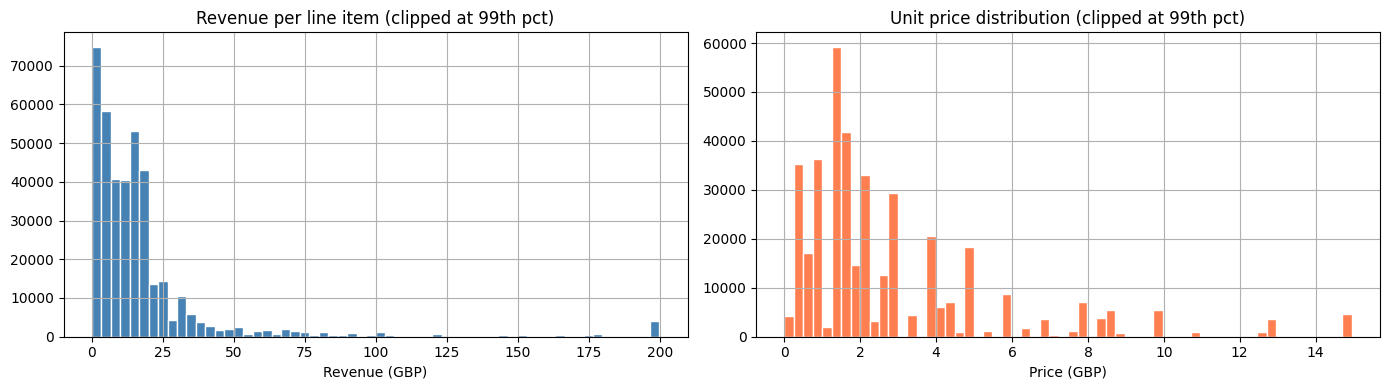

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tx['Revenue'].clip(upper=tx['Revenue'].quantile(0.99)).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Revenue per line item (clipped at 99th pct)')
axes[0].set_xlabel('Revenue (GBP)')
tx['UnitPrice'].clip(upper=tx['UnitPrice'].quantile(0.99)).hist(bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Unit price distribution (clipped at 99th pct)')
axes[1].set_xlabel('Price (GBP)')
plt.tight_layout()
plt.show()

## 5. Top 20 products by revenue

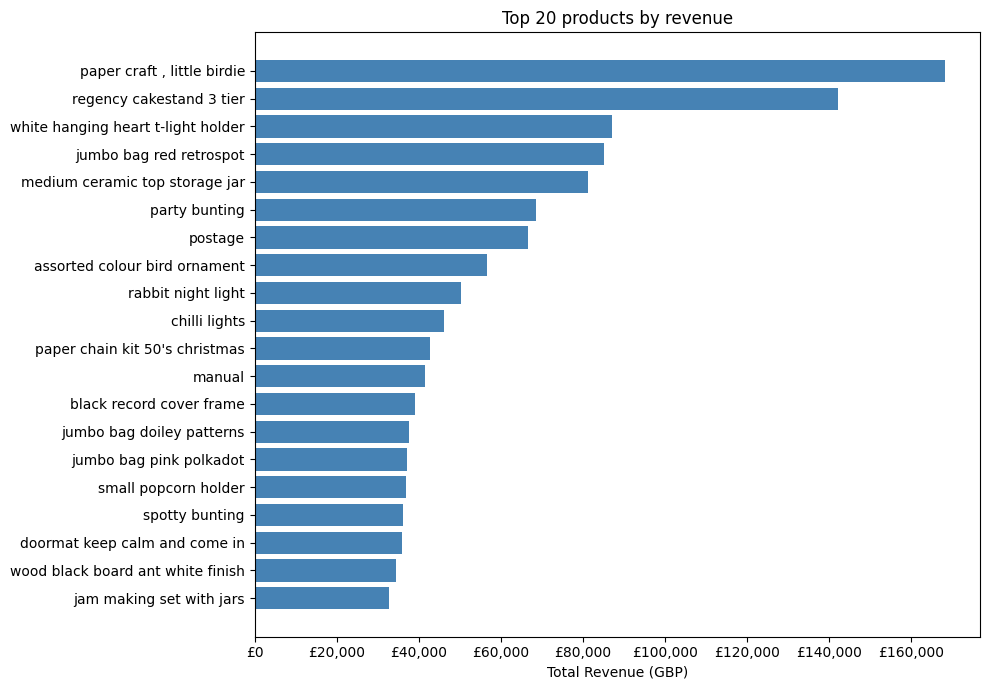

In [7]:
top20 = products.nsmallest(20, 'revenue_rank')[['description','total_revenue','total_quantity','avg_unit_price','num_customers']]
top20 = top20.sort_values('total_revenue', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['description'], top20['total_revenue'], color='steelblue')
ax.set_xlabel('Total Revenue (GBP)')
ax.set_title('Top 20 products by revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

## 6. Revenue by country

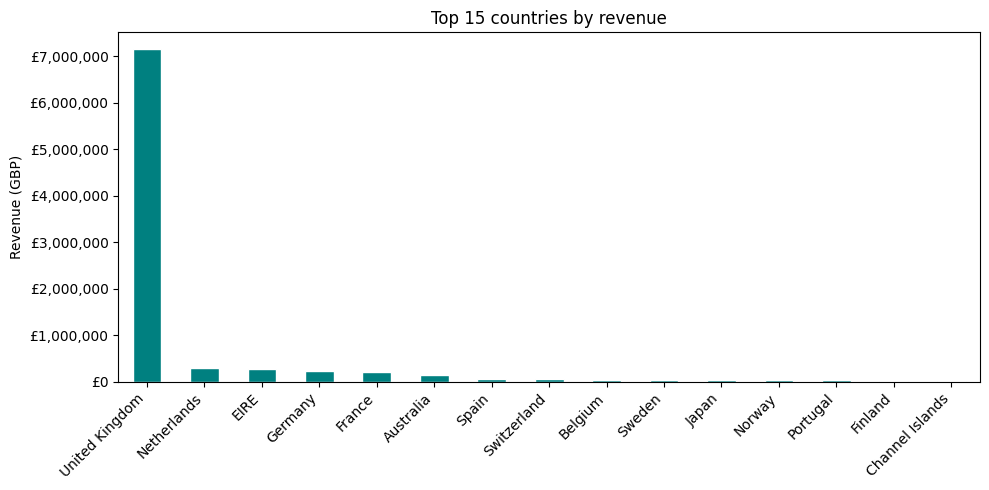

In [8]:
by_country = tx.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5))
by_country.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Top 15 countries by revenue')
ax.set_xlabel('')
ax.set_ylabel('Revenue (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Monthly revenue trend

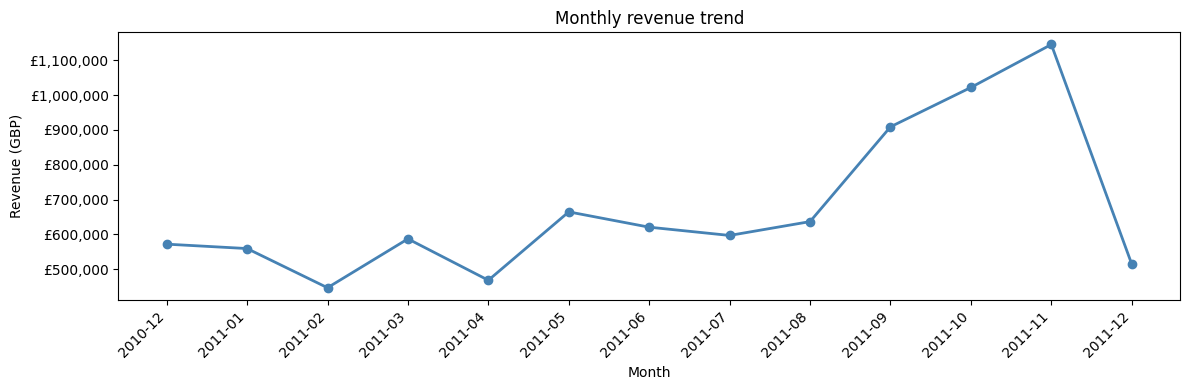

In [9]:
rev_trend = tx.groupby('InvoiceMonth')['Revenue'].sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rev_trend['InvoiceMonth'], rev_trend['Revenue'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly revenue trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Orders by day of week and hour

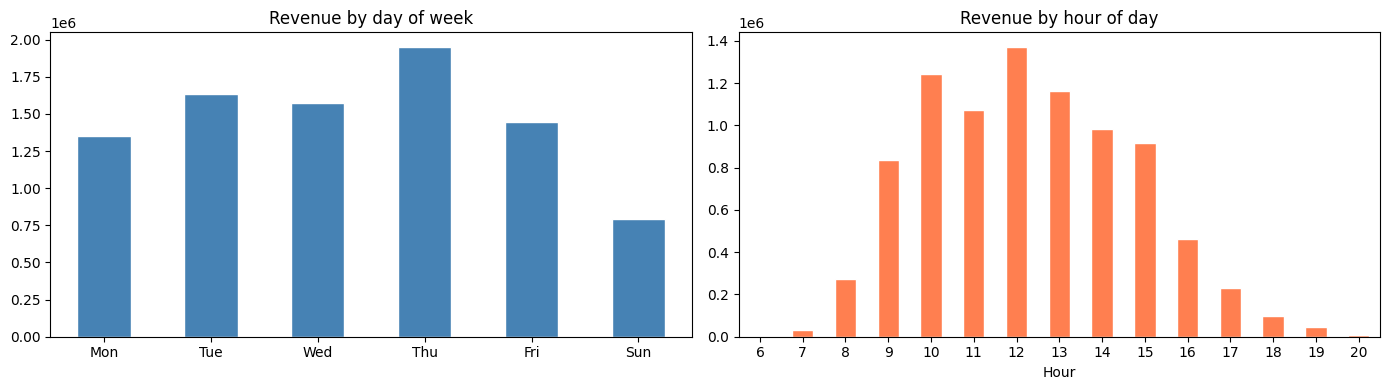

In [10]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tx.groupby('DayOfWeek')['Revenue'].sum().rename(index=dict(enumerate(days))).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Revenue by day of week')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
tx.groupby('Hour')['Revenue'].sum().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Revenue by hour of day')
axes[1].set_xlabel('Hour')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 9. Price statistics summary

In [11]:
print('=== Price statistics across all products ===')
print(products[['avg_unit_price','min_unit_price','max_unit_price','price_range','price_cv']].describe().round(2))
print('\n=== Products with highest price volatility (top 10) ===')
products.nlargest(10, 'price_cv')[['description','avg_unit_price','price_range','price_cv','total_revenue']]

=== Price statistics across all products ===
       avg_unit_price  min_unit_price  max_unit_price  price_range  price_cv
count         3665.00         3665.00         3665.00      3665.00   3484.00
mean             3.58            2.72            5.33         2.60      0.14
std             13.43            5.54           58.67        58.19      0.21
min              0.00            0.00            0.00         0.00      0.00
25%              0.95            0.72            1.25         0.00      0.00
50%              1.94            1.45            2.46         0.40      0.04
75%              3.77            3.00            4.25         1.40      0.21
max            687.14          145.00         3155.95      3155.89      3.18

=== Products with highest price volatility (top 10) ===


,description,avg_unit_price,price_range,price_cv,total_revenue
3662,manual,133.49,3155.89,3.18,41508.49
3204,blue charlie+lola personal doorsign,0.72,2.57,1.20,512.80
3205,red charlie+lola personal doorsign,0.62,2.57,1.19,622.64
2497,yellow breakfast cup and saucer,0.87,2.56,1.19,31.91
480,set/4 daisy mirror magnets,0.53,1.81,1.17,166.57
483,set/4 bird mirror magnets,0.52,1.81,1.17,165.77
1463,pens assorted spaceball,0.27,1.44,1.12,1219.88
523,mirrored wall art table lamp,1.33,5.04,1.11,75.73
3207,charlie+lola my room door sign,0.68,2.16,1.09,205.98
2515,cubic mug pink polkadot,0.62,2.16,1.09,220.95


## 10. Key takeaways
Fill these in after running the notebook:
- Date range: ...
- Dominant market: ...
- Revenue concentration: ...
- Price range: ...
- Seasonality observed: ...